In [1]:
import sys
import os
import glob
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from zhiyi.plot.cbar import Cbar


In [2]:

START = pd.Timestamp("2017-12-01", tz="UTC")
END = pd.Timestamp("2018-12-01", tz="UTC")

MET_GPKG = {
    "O3": "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg",
    "PM25": "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg",
}

MUSICA_DIR = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regirdded_fv01"
MUSICA_FILES = (
    sorted(glob.glob(f"{MUSICA_DIR}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2017-12.nc"))
    + sorted(glob.glob(f"{MUSICA_DIR}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2018-??.nc"))
)
if not MUSICA_FILES:
    raise FileNotFoundError(f"No MUSICA files found in {MUSICA_DIR}")

NE_SHP = "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"
PROJ = ccrs.PlateCarree()
MAP_EXTENT = [-10, 2, 50, 59]
XTICKS = np.arange(-10.5, 3, 2)
YTICKS = np.arange(49.5, 62, 2)

MAIN_CMAP = Cbar("myct_cont").cmap
DIFF_CMAP = plt.get_cmap("RdBu_r")

SAVE_FIGURE = False
FIGURE_OUT = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/Figure2.png"


def load_admin1_mask():
    ne_admin1 = gpd.read_file(NE_SHP)
    if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
        ne_admin1 = ne_admin1.to_crs(epsg=4326)

    ne_uk = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IMN"])]
    return ne_uk, ne_uk.union_all()


def metoffice_to_grid(gpkg_path, uk_union):
    gdf = gpd.read_file(gpkg_path)
    gdf["stdTime"] = pd.to_datetime(gdf["stdTime"])
    gdf_sel = gdf.loc[(gdf["stdTime"] >= START) & (gdf["stdTime"] < END)].copy()

    gdf_avg = gdf_sel.groupby("gridID", as_index=False).agg(mean_avg=("mean", "mean"))
    gdf_avg = gdf_avg.merge(
        gdf.drop_duplicates("gridID")[["gridID", "geometry"]],
        on="gridID",
        how="left",
    )
    gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry="geometry")

    bounds = gdf_avg.geometry.bounds
    gdf_avg["lon"] = (bounds["minx"] + bounds["maxx"]) / 2
    gdf_avg["lat"] = (bounds["miny"] + bounds["maxy"]) / 2

    pivot = gdf_avg[["lon", "lat", "mean_avg"]].pivot(
        index="lat",
        columns="lon",
        values="mean_avg",
    )

    lat_centers = pivot.index.values.astype(float)
    lon_centers = pivot.columns.values.astype(float)
    dlon = np.median(np.diff(lon_centers))
    dlat = np.median(np.diff(lat_centers))

    lon_edges = np.concatenate((
        [lon_centers[0] - dlon / 2],
        (lon_centers[1:] + lon_centers[:-1]) / 2,
        [lon_centers[-1] + dlon / 2],
    ))
    lat_edges = np.concatenate((
        [lat_centers[0] - dlat / 2],
        (lat_centers[1:] + lat_centers[:-1]) / 2,
        [lat_centers[-1] + dlat / 2],
    ))

    lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)
    lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)

    points = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
        crs="EPSG:4326",
    )
    mask_land = points.within(uk_union).values.reshape(pivot.values.shape)
    met_masked = np.where(mask_land, pivot.values, np.nan)

    return {
        "lat_centers": lat_centers,
        "lon_centers": lon_centers,
        "lon2d": lon2d,
        "lat2d": lat2d,
        "lonc2d": lonc2d,
        "latc2d": latc2d,
        "mask_land": mask_land,
        "met": met_masked,
    }


def open_musica_dataset():
    ds = xr.open_mfdataset(MUSICA_FILES, combine="by_coords")
    lons_deg = xr.where(ds["lon"] > 180, ds["lon"] - 360, ds["lon"])
    return ds.assign_coords(lon=lons_deg).sortby("lon")


def musica_on_met_grid(ds_mus, var_name, factor, grid):
    var_sfc = (ds_mus[var_name] * factor).isel(lev=-1)
    var_mean = var_sfc.mean(dim="time")
    var_on_met = var_mean.interp(
        lat=grid["lat_centers"],
        lon=grid["lon_centers"],
    )
    return np.where(grid["mask_land"], var_on_met.values, np.nan)


def build_panel_data():
    ne_uk, uk_union = load_admin1_mask()
    ds_mus = open_musica_dataset()

    panels = {}
    for var_name, factor_mus in {"O3": 1e9 * 2.0, "PM25": 1e9}.items():
        grid = metoffice_to_grid(MET_GPKG[var_name], uk_union)
        mus = musica_on_met_grid(ds_mus, var_name, factor_mus, grid)
        panels[var_name] = {
            **grid,
            "ne_uk": ne_uk,
            "mus": mus,
            "diff": mus - grid["met"],
        }

    ds_mus.close()
    return panels


/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-11-16T00:00:00.0Z, successfully parsed
  return ogr_read(
/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-12-16T12:00:00.0Z, successfully parsed
  return ogr_read(


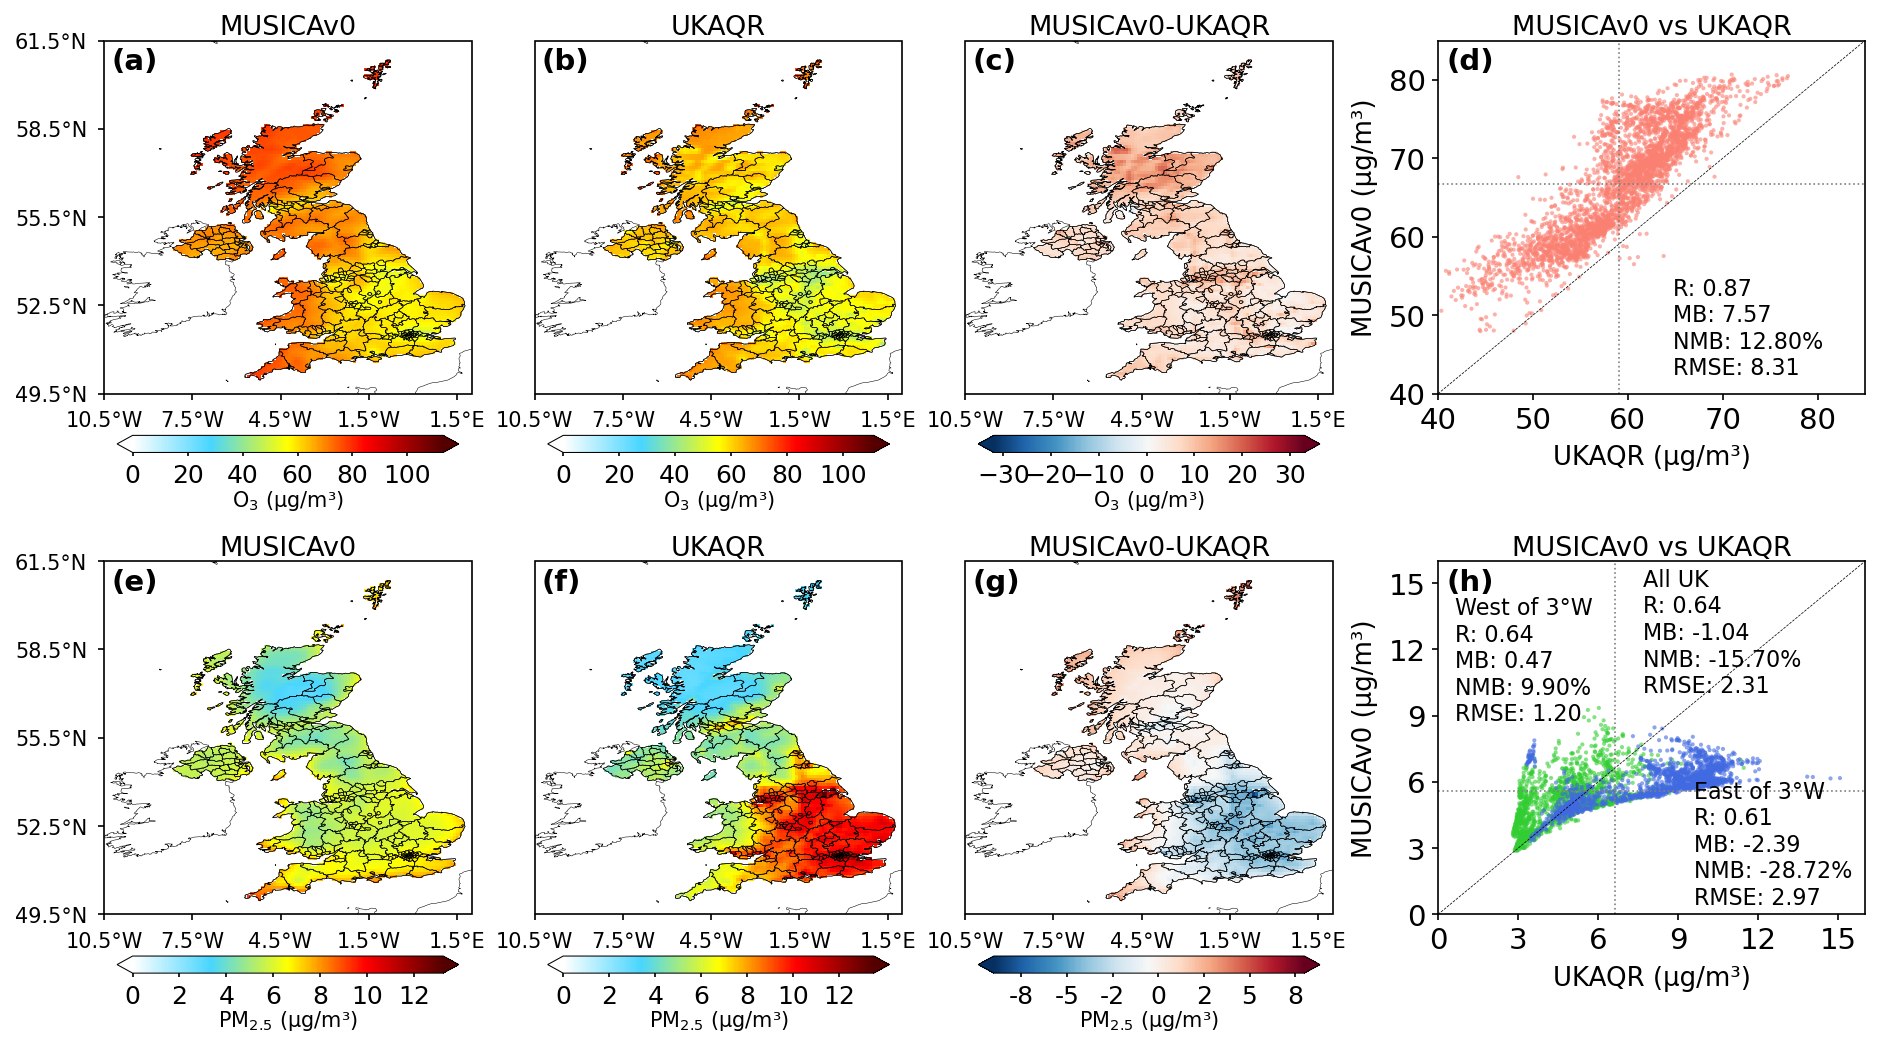

In [ ]:
panels = build_panel_data()

XTICKS = np.arange(-10.5, 3, 3)
YTICKS = np.arange(49.5, 62, 3)


def format_map_axis(ax, panel, show_ylabels=True, show_xlabels=True):
    ax.set_extent(MAP_EXTENT, crs=PROJ)
    ax.coastlines("10m", linewidth=0.25)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.25)
    ax.add_geometries(
        panel["ne_uk"].geometry,
        crs=PROJ,
        facecolor="none",
        edgecolor="black",
        linewidth=0.3,
    )
    ax.set_xticks(XTICKS, crs=PROJ)
    ax.set_yticks(YTICKS, crs=PROJ)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(axis="both", which="major", labelsize=10, length=3, pad=5)
    if not show_ylabels:
        ax.tick_params(labelleft=False,left=False)
    if not show_xlabels:
        ax.tick_params(labelbottom=False)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)


def add_panel_label(ax, label):
    ax.text(
        0.02,
        0.98,
        f"({label})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
    )


def draw_map(ax, panel, data_key, title, label, cmap, vmin, vmax, ticks=None, cbar_format=None, cbar_labelsize=12, cbar_unit=None, cbar_unit_labelsize=12, show_ylabels=True, show_xlabels=True):
    pcm = ax.pcolormesh(
        panel["lon2d"],
        panel["lat2d"],
        panel[data_key],
        shading="auto",
        transform=PROJ,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    format_map_axis(ax, panel, show_ylabels=show_ylabels, show_xlabels=show_xlabels)
    ax.set_title(title, fontsize=13, pad=2)
    add_panel_label(ax, label)

    cb = plt.colorbar(
        pcm,
        ax=ax,
        orientation="horizontal",
        extend="both",
        fraction=0.052,
        pad=0.1,
        shrink=0.8,
        aspect=20,
        ticks=ticks,
        format=cbar_format,
    )
    cb.ax.tick_params(labelsize=cbar_labelsize, length=2, pad=3.5)
    cb.outline.set_linewidth(0.5)
    if cbar_unit is not None:
        cb.ax.text(
                0.5,
                -2.1,
            cbar_unit,
            transform=cb.ax.transAxes,
            ha="center",
            va="top",
            fontsize=12,
        )
    return pcm


def calc_stats(x_sub, y_sub):
    mb = np.mean(y_sub - x_sub)
    rmse = np.sqrt(np.mean((y_sub - x_sub) ** 2))
    corr = np.corrcoef(x_sub, y_sub)[0, 1] if len(x_sub) > 1 else np.nan
    nmb = np.sum(y_sub - x_sub) / np.sum(x_sub) * 100.0
    return corr, mb, nmb, rmse


def draw_scatter(ax, panel, pollutant, label):
    x = panel["met"].ravel()
    y = panel["mus"].ravel()
    lon = panel["lonc2d"].ravel()

    valid = (~np.isnan(x)) & (~np.isnan(y))
    xv = x[valid]
    yv = y[valid]
    lonv = lon[valid]

    threshold = -3.0
    west = lonv < threshold
    east = lonv >= threshold

    if pollutant == "O3":
        xmin, xmax = 40, 85
        ax.scatter(xv[west], yv[west], s=4, alpha=0.6, edgecolor="none", color="salmon")
        ax.scatter(xv[east], yv[east], s=4, alpha=0.6, edgecolor="none", color="salmon")
        ticks = np.arange(xmin, xmax + 1, 10)
        title = "MUSICAv0 vs UKAQR"

        corr, mb, nmb, rmse = calc_stats(xv, yv)
        stats_text = f"R: {corr:.2f}\nMB: {mb:.2f}\nNMB: {nmb:.2f}%\nRMSE: {rmse:.2f}"
        ax.text(0.55, 0.33, stats_text, transform=ax.transAxes, ha="left", va="top", fontsize=10.7)
    else:
        xmin = 0
        xmax = int(np.ceil(max(xv.max(), yv.max())))
        xmax = int(np.ceil(xmax / 2) * 2)
        ax.scatter(xv[west], yv[west], s=4, alpha=0.6, edgecolor="none", color="limegreen")
        ax.scatter(xv[east], yv[east], s=4, alpha=0.6, edgecolor="none", color="royalblue")
        ticks = np.arange(xmin, xmax + 1, 3)
        title = "MUSICAv0 vs UKAQR"

        corr_w, mb_w, nmb_w, rmse_w = calc_stats(xv[west], yv[west])
        corr_e, mb_e, nmb_e, rmse_e = calc_stats(xv[east], yv[east])
        corr_all, mb_all, nmb_all, rmse_all = calc_stats(xv, yv)

        text_w = f"West of 3°W\nR: {corr_w:.2f}\nMB: {mb_w:.2f}\nNMB: {nmb_w:.2f}%\nRMSE: {rmse_w:.2f}"
        text_e = f"East of 3°W\nR: {corr_e:.2f}\nMB: {mb_e:.2f}\nNMB: {nmb_e:.2f}%\nRMSE: {rmse_e:.2f}"
        text_all = f"All UK\nR: {corr_all:.2f}\nMB: {mb_all:.2f}\nNMB: {nmb_all:.2f}%\nRMSE: {rmse_all:.2f}"

        ax.text(0.04, 0.9, text_w, transform=ax.transAxes, ha="left", va="top", fontsize=10.7)
        ax.text(0.6, 0.38, text_e, transform=ax.transAxes, ha="left", va="top", fontsize=10.7)
        ax.text(0.48, 0.98, text_all, transform=ax.transAxes, ha="left", va="top", fontsize=10.7)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    xx = np.linspace(xmin, xmax, 200)
    ax.plot(xx, xx, ls="--", lw=0.35, color="black")
    ax.axvline(np.mean(xv), ls=":", lw=0.8, color="grey")
    ax.axhline(np.mean(yv), ls=":", lw=0.8, color="grey")
    ax.set_aspect("auto")
    ax.tick_params(axis="both", labelsize=14, length=3, pad=3)
    ax.set_xlabel("UKAQR (µg/m³)", fontsize=12.5,labelpad=5)
    ax.set_ylabel("MUSICAv0 (µg/m³)", fontsize=12.5,labelpad=5)
    ax.set_title(title, fontsize=13, pad=2)
    add_panel_label(ax, label)


fig = plt.figure(figsize=(12.7, 7.1), dpi=150)
gs = fig.add_gridspec(
    2,
    5,
    width_ratios=[1, 1, 1, 0.16, 1],
    height_ratios=[1, 1],
    left=0.045,
    right=0.985,
    bottom=0.07,
    top=0.95,
    wspace=0.01,
    hspace=0.25,
)

axes = {
    "a": fig.add_subplot(gs[0, 0], projection=PROJ),
    "b": fig.add_subplot(gs[0, 1], projection=PROJ),
    "c": fig.add_subplot(gs[0, 2], projection=PROJ),
    "d": fig.add_subplot(gs[0, 4]),
    "e": fig.add_subplot(gs[1, 0], projection=PROJ),
    "f": fig.add_subplot(gs[1, 1], projection=PROJ),
    "g": fig.add_subplot(gs[1, 2], projection=PROJ),
    "h": fig.add_subplot(gs[1, 4]),
}

draw_map(
    axes["a"], panels["O3"], "mus",
    "MUSICAv0",
    "a", MAIN_CMAP, 0, 113, ticks=np.arange(0, 101, 20), cbar_unit="O$_3$ (µg/m³)", show_ylabels=True, show_xlabels=True,
)
draw_map(
    axes["b"], panels["O3"], "met",
   "UKAQR",
    "b", MAIN_CMAP, 0, 111, ticks=np.arange(0, 101, 20), cbar_unit="O$_3$ (µg/m³)", show_ylabels=False, show_xlabels=True,
)
draw_map(
    axes["c"], panels["O3"], "diff",
    "MUSICAv0-UKAQR",
    "c", DIFF_CMAP, -32, 33, ticks=np.arange(-30, 31, 10), cbar_unit="O$_3$ (µg/m³)", show_ylabels=False, show_xlabels=True,
)
draw_scatter(axes["d"], panels["O3"], "O3", "d")

draw_map(
    axes["e"], panels["PM25"], "mus",
    "MUSICAv0",
    "e", MAIN_CMAP, 0, 13.25, ticks=np.arange(0, 13, 2), cbar_unit="PM$_{2.5}$ (µg/m³)", show_ylabels=True,
)
draw_map(
    axes["f"], panels["PM25"], "met",
    "UKAQR",
    "f", MAIN_CMAP, 0, 13.5, ticks=np.arange(0, 13, 2), cbar_unit="PM$_{2.5}$ (µg/m³)", show_ylabels=False,
)
draw_map(
    axes["g"], panels["PM25"], "diff",
    "MUSICAv0-UKAQR",
    "g", DIFF_CMAP, -9, 8, ticks=np.arange(-7.5, 8, 2.5), cbar_format="%.0f", cbar_labelsize=12, cbar_unit="PM$_{2.5}$ (µg/m³)", show_ylabels=False,
)
draw_scatter(axes["h"], panels["PM25"], "PM25", "h")


def align_saved_scatter_to_map(scatter_ax, map_ax):
    fig.canvas.draw()
    scatter_pos = scatter_ax.get_position()
    map_pos = map_ax.get_position()
    scatter_ax.set_position([
        scatter_pos.x0,
        map_pos.y0,
        scatter_pos.width,
        map_pos.height,
    ])

align_saved_scatter_to_map(axes["d"], axes["c"])
align_saved_scatter_to_map(axes["h"], axes["g"])



In [6]:
from pathlib import Path

FIGURE_DATA_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data")
FIGURE_DATA_DIR.mkdir(parents=True, exist_ok=True)

nc_out = FIGURE_DATA_DIR / "Figure2.nc"
csv_out = FIGURE_DATA_DIR / "Figure2.csv"

coords = {}
data_vars = {}
rows = []

for pollutant in ["O3", "PM25"]:
    panel = panels[pollutant]
    key = pollutant.lower()
    lat_dim = f"{key}_lat"
    lon_dim = f"{key}_lon"
    lat_edge_dim = f"{key}_lat_edge"
    lon_edge_dim = f"{key}_lon_edge"

    coords[lat_dim] = panel["lat_centers"]
    coords[lon_dim] = panel["lon_centers"]
    coords[lat_edge_dim] = panel["lat2d"][:, 0]
    coords[lon_edge_dim] = panel["lon2d"][0, :]

    data_vars[f"{pollutant}_MUSICAv0"] = ((lat_dim, lon_dim), panel["mus"])
    data_vars[f"{pollutant}_UKAQR"] = ((lat_dim, lon_dim), panel["met"])
    data_vars[f"{pollutant}_MUSICAv0_minus_UKAQR"] = ((lat_dim, lon_dim), panel["diff"])
    data_vars[f"{pollutant}_land_mask"] = ((lat_dim, lon_dim), panel["mask_land"])

    df = pd.DataFrame({
        "pollutant": pollutant,
        "lat": panel["latc2d"].ravel(),
        "lon": panel["lonc2d"].ravel(),
        "MUSICAv0": panel["mus"].ravel(),
        "UKAQR": panel["met"].ravel(),
        "MUSICAv0_minus_UKAQR": panel["diff"].ravel(),
        "land_mask": panel["mask_land"].ravel(),
    })
    rows.append(df.loc[df["land_mask"]].copy())

xr.Dataset(data_vars=data_vars, coords=coords).to_netcdf(nc_out)
pd.concat(rows, ignore_index=True).to_csv(csv_out, index=False)



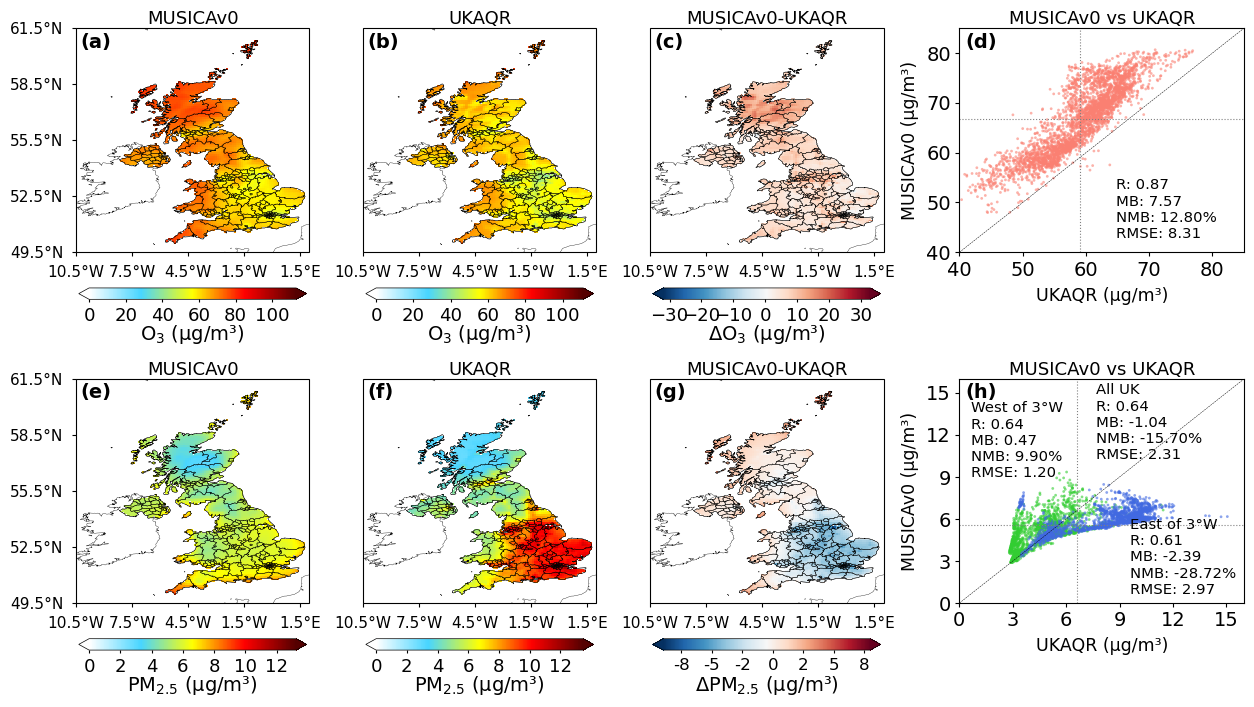

In [21]:
from pathlib import Path

FIGURE_DATA_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data")
nc_in = FIGURE_DATA_DIR / "Figure2.nc"

XTICKS = np.arange(-10.5, 3, 3)
YTICKS = np.arange(49.5, 62, 3)

if not nc_in.exists():
    raise FileNotFoundError(nc_in)

saved_ds = xr.open_dataset(nc_in)

ne_saved = gpd.read_file(NE_SHP)
if ne_saved.crs is None or ne_saved.crs.to_epsg() != 4326:
    ne_saved = ne_saved.to_crs(epsg=4326)
ne_saved_uk = ne_saved[ne_saved["adm0_a3"].isin(["GBR", "IMN"])]

panels_saved = {}
for pollutant in ["O3", "PM25"]:
    key = pollutant.lower()
    lat_centers = saved_ds[f"{key}_lat"].values
    lon_centers = saved_ds[f"{key}_lon"].values
    lat_edges = saved_ds[f"{key}_lat_edge"].values
    lon_edges = saved_ds[f"{key}_lon_edge"].values

    lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)
    lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)

    panels_saved[pollutant] = {
        "lat_centers": lat_centers,
        "lon_centers": lon_centers,
        "lon2d": lon2d,
        "lat2d": lat2d,
        "lonc2d": lonc2d,
        "latc2d": latc2d,
        "mask_land": saved_ds[f"{pollutant}_land_mask"].values.astype(bool),
        "mus": saved_ds[f"{pollutant}_MUSICAv0"].values,
        "met": saved_ds[f"{pollutant}_UKAQR"].values,
        "diff": saved_ds[f"{pollutant}_MUSICAv0_minus_UKAQR"].values,
        "ne_uk": ne_saved_uk,
    }


def format_saved_map_axis(ax, panel, show_ylabels=True, show_xlabels=True):
    ax.set_extent(MAP_EXTENT, crs=PROJ)
    ax.coastlines("10m", linewidth=0.25)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.25)
    ax.add_geometries(
        panel["ne_uk"].geometry,
        crs=PROJ,
        facecolor="none",
        edgecolor="black",
        linewidth=0.3,
    )
    ax.set_xticks(XTICKS, crs=PROJ)
    ax.set_yticks(YTICKS, crs=PROJ)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(axis="both", which="major", labelsize=11, length=3, pad=6)
    if not show_ylabels:
        ax.tick_params(labelleft=False,left=False)
    if not show_xlabels:
        ax.tick_params(labelbottom=False)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)


def add_saved_panel_label(ax, label):
    ax.text(
        0.02,
        0.98,
        f"({label})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
    )


def draw_saved_map(ax, panel, data_key, title, label, cmap, vmin, vmax, ticks=None, cbar_format=None, cbar_labelsize=13, cbar_unit=None, cbar_unit_labelsize=12, show_ylabels=True, show_xlabels=True):
    pcm = ax.pcolormesh(
        panel["lon2d"],
        panel["lat2d"],
        panel[data_key],
        shading="auto",
        transform=PROJ,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        rasterized=True,
    )
    format_saved_map_axis(ax, panel, show_ylabels=show_ylabels, show_xlabels=show_xlabels)
    ax.set_title(title, fontsize=13, pad=3)
    add_saved_panel_label(ax, label)

    cb = plt.colorbar(
        pcm,
        ax=ax,
        orientation="horizontal",
        extend="both",
        fraction=0.052,
        pad=0.13,
        shrink=0.8,
        aspect=20,
        ticks=ticks,
        format=cbar_format,
    )
    cb.ax.tick_params(labelsize=cbar_labelsize, length=2, pad=3.5)
    cb.outline.set_linewidth(0.5)
    if cbar_unit is not None:
        cb.ax.text(
                0.5,
                -2.1,
            cbar_unit,
            transform=cb.ax.transAxes,
            ha="center",
            va="top",
            fontsize=14,
        )
    return pcm


def calc_saved_stats(x_sub, y_sub):
    mb = np.mean(y_sub - x_sub)
    rmse = np.sqrt(np.mean((y_sub - x_sub) ** 2))
    corr = np.corrcoef(x_sub, y_sub)[0, 1] if len(x_sub) > 1 else np.nan
    nmb = np.sum(y_sub - x_sub) / np.sum(x_sub) * 100.0
    return corr, mb, nmb, rmse


def draw_saved_scatter(ax, panel, pollutant, label):
    x = panel["met"].ravel()
    y = panel["mus"].ravel()
    lon = panel["lonc2d"].ravel()

    valid = (~np.isnan(x)) & (~np.isnan(y))
    xv = x[valid]
    yv = y[valid]
    lonv = lon[valid]

    threshold = -3.0
    west = lonv < threshold
    east = lonv >= threshold

    if pollutant == "O3":
        xmin, xmax = 40, 85
        ax.scatter(xv[west], yv[west], s=4, alpha=0.6, edgecolor="none", color="salmon")
        ax.scatter(xv[east], yv[east], s=4, alpha=0.6, edgecolor="none", color="salmon")
        ticks = np.arange(xmin, xmax + 1, 10)
        title = "MUSICAv0 vs UKAQR"

        corr, mb, nmb, rmse = calc_saved_stats(xv, yv)
        stats_text = f"R: {corr:.2f}\nMB: {mb:.2f}\nNMB: {nmb:.2f}%\nRMSE: {rmse:.2f}"
        ax.text(0.55, 0.33, stats_text, transform=ax.transAxes, ha="left", va="top", fontsize=10.7)
    else:
        xmin = 0
        xmax = int(np.ceil(max(xv.max(), yv.max())))
        xmax = int(np.ceil(xmax / 2) * 2)
        ax.scatter(xv[west], yv[west], s=4, alpha=0.6, edgecolor="none", color="limegreen")
        ax.scatter(xv[east], yv[east], s=4, alpha=0.6, edgecolor="none", color="royalblue")
        ticks = np.arange(xmin, xmax + 1, 3)
        title = "MUSICAv0 vs UKAQR"

        corr_w, mb_w, nmb_w, rmse_w = calc_saved_stats(xv[west], yv[west])
        corr_e, mb_e, nmb_e, rmse_e = calc_saved_stats(xv[east], yv[east])
        corr_all, mb_all, nmb_all, rmse_all = calc_saved_stats(xv, yv)

        text_w = f"West of 3°W\nR: {corr_w:.2f}\nMB: {mb_w:.2f}\nNMB: {nmb_w:.2f}%\nRMSE: {rmse_w:.2f}"
        text_e = f"East of 3°W\nR: {corr_e:.2f}\nMB: {mb_e:.2f}\nNMB: {nmb_e:.2f}%\nRMSE: {rmse_e:.2f}"
        text_all = f"All UK\nR: {corr_all:.2f}\nMB: {mb_all:.2f}\nNMB: {nmb_all:.2f}%\nRMSE: {rmse_all:.2f}"

        ax.text(0.04, 0.9, text_w, transform=ax.transAxes, ha="left", va="top", fontsize=10.7)
        ax.text(0.6, 0.38, text_e, transform=ax.transAxes, ha="left", va="top", fontsize=10.7)
        ax.text(0.48, 0.98, text_all, transform=ax.transAxes, ha="left", va="top", fontsize=10.7)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    xx = np.linspace(xmin, xmax, 200)
    ax.plot(xx, xx, ls="--", lw=0.35, color="black")
    ax.axvline(np.mean(xv), ls=":", lw=0.8, color="grey")
    ax.axhline(np.mean(yv), ls=":", lw=0.8, color="grey")
    ax.set_aspect("auto")
    ax.tick_params(axis="both", labelsize=14, length=3, pad=3)
    ax.set_xlabel("UKAQR (µg/m³)", fontsize=12.5,labelpad=5)
    ax.set_ylabel("MUSICAv0 (µg/m³)", fontsize=12.5,labelpad=5)
    ax.set_title(title, fontsize=13, pad=3)
    add_saved_panel_label(ax, label)


fig = plt.figure(figsize=(12.7, 7.1))
gs = fig.add_gridspec(
    2,
    5,
    width_ratios=[1, 1, 1, 0.16, 1],
    height_ratios=[1, 1],
    left=0.045,
    right=0.985,
    bottom=0.07,
    top=0.95,
    wspace=0.01,
    hspace=0.28,
)

axes = {
    "a": fig.add_subplot(gs[0, 0], projection=PROJ),
    "b": fig.add_subplot(gs[0, 1], projection=PROJ),
    "c": fig.add_subplot(gs[0, 2], projection=PROJ),
    "d": fig.add_subplot(gs[0, 4]),
    "e": fig.add_subplot(gs[1, 0], projection=PROJ),
    "f": fig.add_subplot(gs[1, 1], projection=PROJ),
    "g": fig.add_subplot(gs[1, 2], projection=PROJ),
    "h": fig.add_subplot(gs[1, 4]),
}

draw_saved_map(
    axes["a"], panels_saved["O3"], "mus",
    "MUSICAv0",
    "a", MAIN_CMAP, 0, 113, ticks=np.arange(0, 101, 20), cbar_unit="O$_3$ (µg/m³)", show_ylabels=True, show_xlabels=True,
)
draw_saved_map(
    axes["b"], panels_saved["O3"], "met",
   "UKAQR",
    "b", MAIN_CMAP, 0, 111, ticks=np.arange(0, 101, 20), cbar_unit="O$_3$ (µg/m³)", show_ylabels=False, show_xlabels=True,
)
draw_saved_map(
    axes["c"], panels_saved["O3"], "diff",
    "MUSICAv0-UKAQR",
    "c", DIFF_CMAP, -32, 33, ticks=np.arange(-30, 31, 10), cbar_unit="ΔO$_3$ (µg/m³)", show_ylabels=False, show_xlabels=True,
)
draw_saved_scatter(axes["d"], panels_saved["O3"], "O3", "d")

draw_saved_map(
    axes["e"], panels_saved["PM25"], "mus",
    "MUSICAv0",
    "e", MAIN_CMAP, 0, 13.25, ticks=np.arange(0, 13, 2), cbar_unit="PM$_{2.5}$ (µg/m³)", show_ylabels=True,
)
draw_saved_map(
    axes["f"], panels_saved["PM25"], "met",
    "UKAQR",
    "f", MAIN_CMAP, 0, 13.5, ticks=np.arange(0, 13, 2), cbar_unit="PM$_{2.5}$ (µg/m³)", show_ylabels=False,
)
draw_saved_map(
    axes["g"], panels_saved["PM25"], "diff",
    "MUSICAv0-UKAQR",
    "g", DIFF_CMAP, -9, 8, ticks=np.arange(-7.5, 8, 2.5), cbar_format="%.0f", cbar_labelsize=12, cbar_unit="ΔPM$_{2.5}$ (µg/m³)", show_ylabels=False,
)
draw_saved_scatter(axes["h"], panels_saved["PM25"], "PM25", "h")


def align_saved_scatter_to_map(scatter_ax, map_ax):
    fig.canvas.draw()
    scatter_pos = scatter_ax.get_position()
    map_pos = map_ax.get_position()
    scatter_ax.set_position([
        scatter_pos.x0,
        map_pos.y0,
        scatter_pos.width,
        map_pos.height,
    ])

align_saved_scatter_to_map(axes["d"], axes["c"])
align_saved_scatter_to_map(axes["h"], axes["g"])


FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / "Figure2.png"
pdf_path = FIGURES_DIR / "Figure2.pdf"


fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis("off")
pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
plt.close(pdf_fig)


